Process Open Targets 2024-09 update for all disease associations

Open Targets Source: https://platform.opentargets.org/downloads 

Map Ensemble Gene ID to Uniprot: https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/idmapping/by_organism/ 

Use three cutoff values 0.3, 0.5, 0.7

In [2]:
import json
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
open_targets_dir = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/"
association_by_overall_indirect_dir = os.path.join(open_targets_dir, "associationByOverallIndirect")
association_by_datatype_indirect_dir = os.path.join(open_targets_dir, "associationByDatatypeIndirect") # can filter by genetic association
disease_dir = os.path.join(open_targets_dir, "diseases")

In [4]:
af2_human_proteins = [x.replace(".pdb", "") for x in os.listdir("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/UP000005640_9606_HUMAN_v4") if x.endswith(".pdb")]
uniprot_id_mapping = pd.read_csv(os.path.join(open_targets_dir, 'HUMAN_9606_idmapping_selected.tab.gz'), sep='\t', header=None, compression='gzip', usecols=[0, 18], names=['uniprot_id', 'ensembl_gene_id'])
uniprot_id_mapping = uniprot_id_mapping.assign(ensembl_gene_id=uniprot_id_mapping['ensembl_gene_id'].str.split(';')).explode('ensembl_gene_id')
uniprot_id_mapping['ensembl_version'] = uniprot_id_mapping['ensembl_gene_id'].str.split('.', expand=True)[1]
uniprot_id_mapping['ensembl_gene_id'] = uniprot_id_mapping['ensembl_gene_id'].str.split('.', expand=True)[0]
uniprot_id_mapping = uniprot_id_mapping.dropna(subset=['ensembl_gene_id'])
num_uniprot_mapping = len(uniprot_id_mapping)
uniprot_id_mapping = uniprot_id_mapping[uniprot_id_mapping['uniprot_id'].isin(af2_human_proteins)]
print(f"Filtered {num_uniprot_mapping} uniprot mappings to {len(uniprot_id_mapping)} which are in the AF2 human proteome (total {len(af2_human_proteins)} AF2 proteins)")

uniprot_id_mapping = uniprot_id_mapping.drop_duplicates(subset=['ensembl_gene_id'])
print(f"Filtered {len(uniprot_id_mapping)} uniprot mappings to unique ensembl gene ids (removed multiple uniprots that map to one uniprot).")

Filtered 88885 uniprot mappings to 21883 which are in the AF2 human proteome (total 23402 AF2 proteins)
Filtered 21869 uniprot mappings to unique ensembl gene ids (removed multiple uniprots that map to one uniprot).


In [4]:
diseases = []
files_to_process = [x for x in os.listdir(disease_dir) if x.endswith(".json")]
for fname in tqdm(files_to_process, desc="diseases", total=len(files_to_process)):
    json_file = os.path.join(disease_dir, fname)
    with open(json_file) as f:
        df = pd.DataFrame([json.loads(line) for line in f.readlines()])
        diseases.append(df)
diseases_df = pd.concat(diseases)
diseases_id_to_name = diseases_df[["id", "name"]].set_index("id").to_dict()["name"]

diseases: 100%|██████████| 200/200 [00:08<00:00, 24.15it/s]


In [5]:
diseases_df['id'].apply(lambda x: x.split("_")[0]).value_counts()

id
EFO         12548
MONDO       11289
Orphanet     2045
HP           1836
GO            479
OBA           105
OTAR            9
DOID            6
OBI             4
NCIT            3
MP              2
OGMS            1
Name: count, dtype: int64

In [6]:
association_by_overall_indirect = []
files_to_process = [x for x in os.listdir(association_by_overall_indirect_dir) if x.endswith(".json")]
for fname in tqdm(files_to_process, desc="associationByDatatypeIndirect", total=len(files_to_process)):
    json_file = os.path.join(association_by_overall_indirect_dir, fname)
    with open(json_file) as f:
        df = pd.DataFrame([json.loads(line) for line in f.readlines()])
        association_by_overall_indirect.append(df)
association_by_overall_indirect_df = pd.concat(association_by_overall_indirect)
association_by_overall_indirect_df.to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/associationByOverallIndirect.csv', index=False)

associationByDatatypeIndirect: 100%|██████████| 200/200 [00:43<00:00,  4.60it/s]


In [8]:
association_by_datatype_indirect = []
files_to_process = [x for x in os.listdir(association_by_datatype_indirect_dir) if x.endswith(".json")]
for fname in tqdm(files_to_process, desc="associationByDatatypeIndirect", total=len(files_to_process)):
    json_file = os.path.join(association_by_datatype_indirect_dir, fname)
    with open(json_file) as f:
        df = pd.DataFrame([json.loads(line) for line in f.readlines()])
        association_by_datatype_indirect.append(df)
association_by_datatype_indirect_df = pd.concat(association_by_datatype_indirect)
association_by_datatype_indirect_df.to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/associationByDatatypeIndirect.csv', index=False)

associationByDatatypeIndirect: 100%|██████████| 200/200 [00:53<00:00,  3.75it/s]


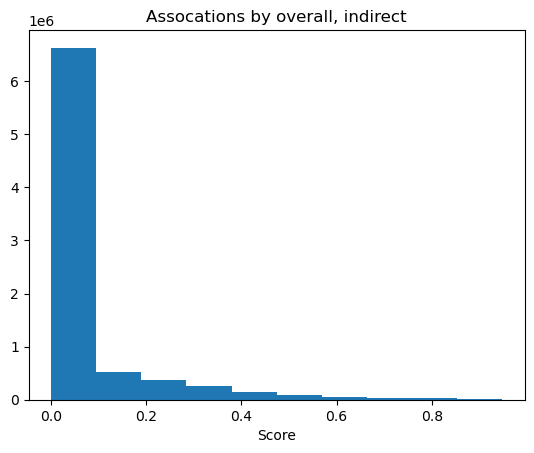

In [7]:
plt.hist(association_by_overall_indirect_df['score'])
plt.title("Assocations by overall, indirect")
plt.xlabel("Score")
plt.show()

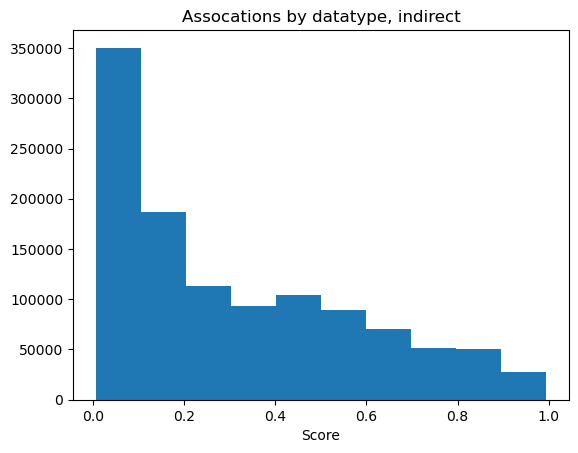

In [8]:
plt.hist(association_by_datatype_indirect_df[association_by_datatype_indirect_df['datatypeId'].isin(['genetic_association','somantic_mutation'])]['score'])
plt.title("Assocations by datatype, indirect")
plt.xlabel("Score")
plt.show()

In [8]:
# map to uniprot
association_by_overall_indirect = pd.read_csv(os.path.join(open_targets_dir, "associationByOverallIndirect.csv"))
overlapping_uniprots = set(uniprot_id_mapping['ensembl_gene_id'].values.tolist()).intersection(set(association_by_overall_indirect['targetId'].values.tolist()))
num_overlapping_uniprots = len(overlapping_uniprots)
num_genes = len(set(association_by_overall_indirect['targetId'].values.tolist()))
print(f"Number of overlapping genes to uniprot: {num_overlapping_uniprots} out of {num_genes}")
association_by_overall_indirect = association_by_overall_indirect[association_by_overall_indirect['targetId'].isin(overlapping_uniprots)]
association_by_overall_indirect['uniprot_targetId'] = association_by_overall_indirect['targetId'].map(uniprot_id_mapping.set_index('ensembl_gene_id')['uniprot_id'])
association_by_overall_indirect.to_csv(os.path.join(open_targets_dir, "associationByOverallIndirect_uniprot.csv"), index=False)

Number of overlapping genes to uniprot: 19038 out of 30315


In [10]:
CUTOFF = 0.5

# filter for genetic evidence and somatic mutation
association_by_datatype_indirect_filtered_df = association_by_datatype_indirect_df[association_by_datatype_indirect_df['score'] > CUTOFF]

# map to uniprot
overlapping_uniprots = set(uniprot_id_mapping['ensembl_gene_id'].values.tolist()).intersection(set(association_by_datatype_indirect_filtered_df['targetId'].values.tolist()))
num_overlapping_uniprots = len(overlapping_uniprots)
num_genes = len(set(association_by_datatype_indirect_filtered_df['targetId'].values.tolist()))
print(f"Number of overlapping genes to uniprot: {num_overlapping_uniprots} out of {num_genes}")
association_by_datatype_indirect_filtered_df = association_by_datatype_indirect_filtered_df[association_by_datatype_indirect_filtered_df['targetId'].isin(overlapping_uniprots)]
association_by_datatype_indirect_filtered_df['uniprot_targetId'] = association_by_datatype_indirect_filtered_df['targetId'].map(uniprot_id_mapping.set_index('ensembl_gene_id')['uniprot_id'])

# map to disease names
association_by_datatype_indirect_filtered_df['diseaseName'] = association_by_datatype_indirect_filtered_df['diseaseId'].map(diseases_id_to_name)
disease_counts = association_by_datatype_indirect_filtered_df.groupby(['diseaseId', 'diseaseName']).size().sort_values(ascending=False).reset_index(name='count')
disease_counts = disease_counts[disease_counts['count'] > 25]
out_path = os.path.join(open_targets_dir, f"association_by_datatype_indirect_disease_counts_cutoff_{CUTOFF}.csv")
association_by_datatype_indirect_filtered_df.to_csv(out_path, index=False)
print(f"Num diseases with > 25 associations: {len(disease_counts)}")
print(f"Saved associations to {out_path}")

Number of overlapping genes to uniprot: 16634 out of 17823
Num diseases with > 25 associations: 3260
Saved associations to /n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_datatype_indirect_disease_counts_cutoff_0.5.csv


In [10]:
association_by_overall_indirect_df

,diseaseId,targetId,score,evidenceCount
0,GO_0032940,ENSG00000091831,0.001478,1
1,GO_0032940,ENSG00000101200,0.001478,1
2,GO_0032940,ENSG00000112164,0.369580,1
3,GO_0032940,ENSG00000113580,0.369580,1
4,GO_0032940,ENSG00000115138,0.001478,1
...,...,...,...,...
44833,Orphanet_183494,ENSG00000278540,0.002957,1
44834,Orphanet_183494,ENSG00000280371,0.007392,1
44835,Orphanet_183494,ENSG00000283733,0.036662,1
44836,Orphanet_183494,ENSG00000284883,0.012145,4


In [11]:
CUTOFF = 0.5

# filter for genetic evidence and somatic mutation
association_by_overall_indirect_filtered_df = association_by_overall_indirect_df[association_by_overall_indirect_df['score'] > CUTOFF]

# map to uniprot
overlapping_uniprots = set(uniprot_id_mapping['ensembl_gene_id'].values.tolist()).intersection(set(association_by_overall_indirect_filtered_df['targetId'].values.tolist()))
num_overlapping_uniprots = len(overlapping_uniprots)
num_genes = len(set(association_by_overall_indirect_filtered_df['targetId'].values.tolist()))
print(f"Number of overlapping genes to uniprot: {num_overlapping_uniprots} out of {num_genes}")
association_by_overall_indirect_filtered_df = association_by_overall_indirect_filtered_df[association_by_overall_indirect_filtered_df['targetId'].isin(overlapping_uniprots)]
association_by_overall_indirect_filtered_df['uniprot_targetId'] = association_by_overall_indirect_filtered_df['targetId'].map(uniprot_id_mapping.set_index('ensembl_gene_id')['uniprot_id'])

# map to disease names
association_by_overall_indirect_filtered_df['diseaseName'] = association_by_overall_indirect_filtered_df['diseaseId'].map(diseases_id_to_name)
disease_counts = association_by_overall_indirect_filtered_df.groupby(['diseaseId', 'diseaseName']).size().sort_values(ascending=False).reset_index(name='count')
disease_counts = disease_counts[disease_counts['count'] > 25]
out_path = os.path.join(open_targets_dir, f"association_by_overall_indirect_disease_counts_cutoff_{CUTOFF}.csv")
association_by_overall_indirect_filtered_df.to_csv(out_path, index=False)
print(f"Num diseases with > 25 associations: {len(disease_counts)}")
print(f"Saved associations to {out_path}")

Number of overlapping genes to uniprot: 7625 out of 7789
Num diseases with > 25 associations: 883
Saved associations to /n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv


In [12]:
disease_counts

,diseaseId,diseaseName,count
0,OTAR_0000018,"genetic, familial or congenital disease",1674
1,EFO_0000508,genetic disorder,1648
2,EFO_0000618,nervous system disease,650
3,EFO_0000589,metabolic disease,525
4,OTAR_0000020,nutritional or metabolic disease,525
...,...,...,...
134,MONDO_0015547,hereditary dementia,27
135,MONDO_0021026,hereditary epidermal appendage anomaly,26
136,MONDO_0019287,ectodermal dysplasia syndrome,26
137,EFO_0009566,renal tubule disease,26


In [17]:
chosen_diseases = [
    'OTAR_0000020',
    'EFO_0003869',
    'EFO_0000574',
    'MONDO_0004736',
    'EFO_0004142',
    'EFO_0000318',
    'EFO_0001645',
    'EFO_0005950',
    'MONDO_0002525',
    'MONDO_0019214',
    'MONDO_0005148',
    'MONDO_0005301',
    'EFO_0009533',
    'MONDO_0004643',
    'EFO_0000538',
    'EFO_0003782',
    'EFO_0000691',
    'MONDO_0000437',
    'EFO_0003763',
    'MONDO_0002561',
    'EFO_0009544',
    'EFO_0009566',
    'EFO_0009314',
    'EFO_0009085',
    'EFO_0009086',
    'MONDO_0015626',
    'MONDO_0019064',
    'MONDO_0015909',
    'EFO_0005539',
    'MONDO_0004979',
    'MONDO_0002887',
    'EFO_0000195',
    'MONDO_0004975',
    'EFO_0004251',
    'EFO_0000681',
    'MONDO_0002245',
    'MONDO_0019254',
    'Orphanet_98693',
    'MONDO_0004976',
    'EFO_0000685',
    'MONDO_0003689',
    'EFO_0000676',
    'EFO_0009606',
    'MONDO_0016761',
    'MONDO_0019053',
    'Orphanet_309005',
    'MONDO_0019625',
    'EFO_0003872',
]

chosen_disease_associations = association_by_overall_indirect_filtered_df[association_by_overall_indirect_filtered_df['diseaseId'].isin(chosen_diseases)] 
out_path = os.path.join(open_targets_dir, f"diamond_association_by_overall_indirect_disease_counts_cutoff_{CUTOFF}.csv")
print("Saving to", out_path)
chosen_disease_associations.to_csv(out_path, index=False) 
chosen_disease_associations

Saving to /n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/diamond_association_by_overall_indirect_disease_counts_cutoff_0.5.csv


,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
16234,MONDO_0015909,ENSG00000008988,0.583261,13,P60866,aplastic anemia
16253,MONDO_0015909,ENSG00000012048,0.828619,396,P38398,aplastic anemia
16254,MONDO_0015909,ENSG00000012061,0.506229,27,P07992,aplastic anemia
16333,MONDO_0015909,ENSG00000051180,0.729512,112,Q06609,aplastic anemia
16366,MONDO_0015909,ENSG00000063177,0.500341,6,Q07020,aplastic anemia
...,...,...,...,...,...,...
39844,MONDO_0019214,ENSG00000164708,0.775764,157,P15259,inborn carbohydrate metabolic disorder
39882,MONDO_0019214,ENSG00000168291,0.781997,378,P11177,inborn carbohydrate metabolic disorder
39894,MONDO_0019214,ENSG00000169738,0.609981,9,Q7Z4W1,inborn carbohydrate metabolic disorder
39897,MONDO_0019214,ENSG00000170266,0.861648,1810,P16278,inborn carbohydrate metabolic disorder
